In [ ]:
##ANÁLISIS DEL ENTORNO Y OPTIMIZACIÓN: AGUACATES MONARCA

##1. CONTEXTO Y MERCADO DEL AGUACATE EN MÉXICO
##México lidera la producción mundial de aguacate, controlando más del 30% de la
##oferta global con un volumen anual de entre 2.4 y 2.5 millones de toneladas.
##El estado de Michoacán es el principal productor nacional (~73%), debido a sus
##suelos volcánicos y microclimas que permiten cosechas continuas a lo largo de
#sus cuatro olas fenológicas (Loca, Aventajada, Normal y Marceña).

#El aguacate es un fruto CLIMATÉRICO: su proceso de maduración inicia únicamente
#DESPUÉS de ser cortado del árbol. Mantener una cadena de frío estricta (4°C a 7°C)
#y una logística de transporte eficiente es crítico para evitar la sobremaduración
#y la pérdida del valor comercial del producto.

#En este marco, la región de Zitácuaro, Michoacán, actúa como un nodo logístico
#clave para articular los flujos de mercancía desde las huertas hacia los centros
#de consumo masivo, como la Central de Abastos de la CDMX.

#2. PLANTEAMIENTO DEL PROBLEMA DE OPTIMIZACIÓN

#Buscamos maximizar la ganancia neta de "Aguacates Monarca" determinando la mezcla
#ideal de compra diaria entre dos proveedores, bajo las siguientes condiciones:

#Variables de Decisión:
 # * x1 = Cajas de la Central de Abastos (Ganancia: $84.34/caja | Costo: $590.66)
 #* x2 = Cajas de Michoacán          (Ganancia: $185.50/caja | Costo: $489.50)

#Restricciones del Sistema:
  #1. Presupuesto de Compra: Máximo $20,000 MXN.
 # 2. Capacidad de Almacén: Máximo 35 cajas.
  #3. Política Comercial: x1 no puede superar el 40% del total (x2 >= 1.5 * x1).
   #  Además, se deben comprar mínimo 5 cajas en la Central (x1 >= 5).
  #4. Presupuesto de Gasolina: Máximo $1,200 MXN para transporte.
   #  (Flete Central = $15/caja | Flete Michoacán = $65/caja).


Resultados de la Optimización con Restricción de Gasolina:
Cajas Central (x1): 10.67
Cajas Michoacán (x2): 16.00
Total de cajas: 26.67
Ganancia Máxima: $3,867.63 MXN


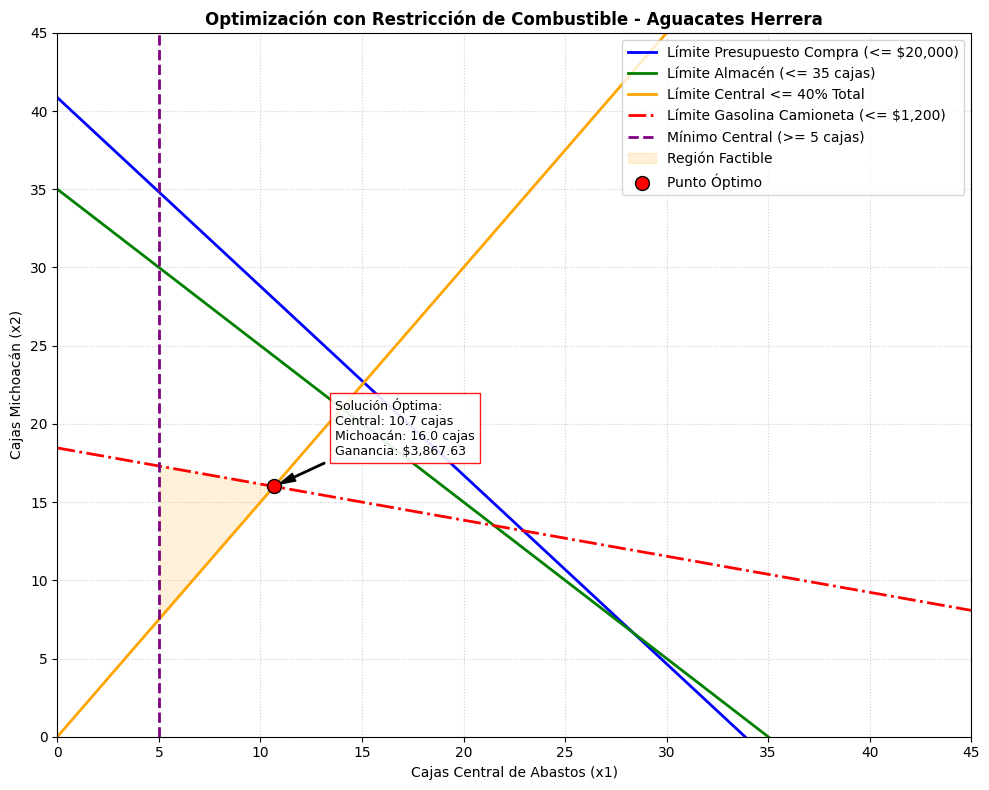

In [ ]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

plt.style.use('default')

# 1. RESOLVER LA OPTIMIZACIÓN CON 4 RESTRICCIONES


# Coeficientes de ganancia (en negativo para maximizar)
c = [-84.34, -185.50]

# Matriz de restricciones (Lado izquierdo: <=)
# Fila 1: Presupuesto de Compra (590.66*x1 + 489.50*x2 <= 20000)
# Fila 2: Almacén (1*x1 + 1*x2 <= 35)
# Fila 3: Porcentaje de la Central (0.60*x1 - 0.40*x2 <= 0)
# Fila 4: NUEVA - Presupuesto Gasolina (15*x1 + 65*x2 <= 1200)
A = np.array([
    [590.66, 489.50],
    [1.0,    1.0],
    [0.60,  -0.40],
    [15.00,  65.00]  # Costo de gas por caja (Central vs Michoacán)
])

# Vector de límites (Lado derecho: <=)
# Se añade el límite de $1,200 MXN para gasto de gasolina
b = [20000, 35, 0, 1200]

# Límites de las variables:
bounds = [(5, None), (0, None)]

# Ejecutar el modelo
solucion = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

# Guardar los valores optimizados
cajas_central = solucion.x[0]
cajas_michoacan = solucion.x[1]
ganancia_max = -solucion.fun

print("Resultados de la Optimización con Restricción de Gasolina:")
print(f"Cajas Central (x1): {cajas_central:.2f}")
print(f"Cajas Michoacán (x2): {cajas_michoacan:.2f}")
print(f"Total de cajas: {cajas_central + cajas_michoacan:.2f}")
print(f"Ganancia Máxima: ${ganancia_max:,.2f} MXN")


# 2. GENERAR LA GRÁFICA


x1 = np.linspace(0, 45, 500)

# Despejes de las restricciones para graficar
x2_presupuesto = (20000 - 590.66 * x1) / 489.50
x2_almacen = 35 - x1
x2_porcentaje = (0.60 / 0.40) * x1
x2_gasolina = (1200 - 15 * x1) / 65.00  # Despeje de la nueva restricción

plt.figure(figsize=(10, 8))

# Trazar las líneas de restricción
plt.plot(x1, x2_presupuesto, label='Límite Presupuesto Compra (<= $20,000)', color='blue', linewidth=2)
plt.plot(x1, x2_almacen, label='Límite Almacén (<= 35 cajas)', color='green', linewidth=2)
plt.plot(x1, x2_porcentaje, label='Límite Central <= 40% Total', color='orange', linewidth=2)
plt.plot(x1, x2_gasolina, label='Límite Gasolina Camioneta (<= $1,200)', color='red', linestyle='-.', linewidth=2)
plt.axvline(x=5, color='purple', linestyle='--', linewidth=2, label='Mínimo Central (>= 5 cajas)')

# --- Región Factible Adaptada ---
# El límite superior ahora considera también la línea de la gasolina
limite_superior = np.minimum(np.minimum(x2_presupuesto, x2_almacen), x2_gasolina)
limite_inferior = x2_porcentaje

plt.fill_between(x1, limite_inferior, limite_superior,
                 where=(limite_superior >= limite_inferior) & (x1 >= 5),
                 color='orange', alpha=0.15, label='Región Factible')

# Marcar el Nuevo Punto Óptimo
plt.scatter(cajas_central, cajas_michoacan, color='red', s=100, edgecolors='black', zorder=6, label='Punto Óptimo')

# Anotación en la gráfica
texto_optimo = f"Solución Óptima:\nCentral: {cajas_central:.1f} cajas\nMichoacán: {cajas_michoacan:.1f} cajas\nGanancia: ${ganancia_max:,.2f}"
plt.annotate(texto_optimo,
             xy=(cajas_central, cajas_michoacan),
             xytext=(cajas_central + 3, cajas_michoacan + 2),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=9,
             bbox=dict(boxstyle='square,pad=0.4', facecolor='white', edgecolor='red', alpha=0.9))

# Detalles del plano
plt.xlim(0, 45)
plt.ylim(0, 45)
plt.title('Optimización con Restricción de Combustible - Aguacates Herrera', fontsize=12, weight='bold')
plt.xlabel('Cajas Central de Abastos (x1)')
plt.ylabel('Cajas Michoacán (x2)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()